# ***Pré-requis***

In [ ]:
# 1. Nettoyage complet des fichiers et installations existantes
!rm -rf spark-3.4.1-bin-hadoop3*
!apt-get purge -qq openjdk-8-jdk-headless
!pip uninstall -y pyspark findspark

# 2. Réinstallation de Java 8
!apt-get update -qq
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# 3. Téléchargement et extraction de Spark 3.4.1
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz

# 4. Installation des dépendances Python
!pip install -q findspark pyspark==3.4.1

# 5. Configuration des variables d’environnement
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

# 6. Forcer le redémarrage du runtime pour valider les changements
print("Installation terminée. Redémarrage du runtime en cours... Re-exécutez cette cellule après le redémarrage.")
os.kill(os.getpid(), 9)

(Reading database ... 119020 files and directories currently installed.)
Removing openjdk-8-jdk-headless:amd64 (8u482-ga~us1-0ubuntu1~22.04) ...
Found existing installation: pyspark 3.4.1
Uninstalling pyspark-3.4.1:
  Successfully uninstalled pyspark-3.4.1
Found existing installation: findspark 2.0.1
Uninstalling findspark-2.0.1:
  Successfully uninstalled findspark-2.0.1
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.4.1 which is incompatible.


In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

# Initialisation de la session Spark
spark = SparkSession.builder \
    .appName("MeteoProjectFinal") \
    .master("local[*]") \
    .getOrCreate()

print("Spark est prêt et la session est active ! ✅")

Spark est prêt et la session est active ! ✅


# ***Chargement et nettoyage***

In [ ]:
from pyspark.sql.functions import to_timestamp, round, col

# Charger le fichier
df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/fichier_plat_stockage/weatherHistory.csv', header=True, inferSchema=True)

# 1. Voir un aperwu initial
df.show(5)

# 2. Nettoyage : Supprimer la colonne 'Loud Cover'
df_clean = df.drop("Loud Cover")

## 3. Gerer les valeurs manquantes pour 'Precip Type'
#df_clean = df_clean.fillna({'Precip Type': 'null'})

# Supprime les lignes identiques
df_clean = df.dropDuplicates()

# On garde les températures réalistes (ex: entre -50 et +60 degrés)
df_clean = df_clean.filter((df_clean["Temperature (C)"] > -50) & (df_clean["Temperature (C)"] < 60))

# 4. Conversion de la date avec le format specifie
df_clean = df_clean.withColumn("Formatted Date", to_timestamp("Formatted Date", "yyyy-MM-dd HH:mm:ss.SSS Z"))

# 5. Arrondir les colonnes numeriques & deux decimales
numeric_cols = [c for c, t in df_clean.dtypes if t in ['double', 'int', 'float']]
for column in numeric_cols:
    df_clean = df_clean.withColumn(column, round(col(column), 2))


# 6. Verifier le resultat
df_clean.printSchema()
df_clean.show(5)

+-------------------+-------------+-----------+-----------------+------------------------+--------+------------------+----------------------+------------------+----------+--------------------+--------------------+
|     Formatted Date|      Summary|Precip Type|  Temperature (C)|Apparent Temperature (C)|Humidity| Wind Speed (km/h)|Wind Bearing (degrees)|   Visibility (km)|Loud Cover|Pressure (millibars)|       Daily Summary|
+-------------------+-------------+-----------+-----------------+------------------------+--------+------------------+----------------------+------------------+----------+--------------------+--------------------+
|2006-03-31 22:00:00|Partly Cloudy|       rain|9.472222222222221|      7.3888888888888875|    0.89|           14.1197|                 251.0|15.826300000000002|       0.0|             1015.13|Partly cloudy thr...|
|2006-03-31 23:00:00|Partly Cloudy|       rain|9.355555555555558|       7.227777777777776|    0.86|           14.2646|                 259.0|15.

In [ ]:
from pyspark.sql.functions import col

# 1. Justification : Les valeurs 'null' dans 'Precip Type' sont supprimées car elles représentent
# des informations manquantes qui pourraient fausser l'analyse des précipitations.

# 2. Suppression des lignes où 'Precip Type' est 'null'
df_clean = df_clean.filter(col("Precip Type") != "null")

# 3. Afficher la nouvelle taille de la table
nouvelle_taille = df_clean.count()
print(f"Nettoyage effectué. Nouvelle taille de la table : {nouvelle_taille} lignes.")

Nettoyage effectué. Nouvelle taille de la table : 95912 lignes.


# ***Modelisation (Data Warehouse)***

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id, year, month, dayofmonth, hour, col

# ---------------------------------------------------------
# 1. Création de la Dimension Condition (Dim_Condition)
# ---------------------------------------------------------
# On sélectionne les colonnes uniques, on supprime les doublons et on ajoute un ID
dim_condition = df_clean.select("Summary", "Precip Type").distinct() \
                        .withColumn("ID_Condition", monotonically_increasing_id())

print("Aperçu de Dim_Condition :")
dim_condition.show(5)

# ---------------------------------------------------------
# 2. Création de la Dimension Temps (Dim_Temps)
# ---------------------------------------------------------
# On extrait les informations temporelles de la date formatée
dim_temps = df_clean.select(col("Formatted Date").alias("Date_Complete")).distinct() \
                    .withColumn("Annee", year("Date_Complete")) \
                    .withColumn("Mois", month("Date_Complete")) \
                    .withColumn("Jour", dayofmonth("Date_Complete")) \
                    .withColumn("Heure", hour("Date_Complete")) \
                    .withColumn("ID_Temps", monotonically_increasing_id())

print("Aperçu de Dim_Temps :")
dim_temps.show(5)

# ---------------------------------------------------------
# 3. Création de la Table de Faits (Fait_Releves)
# ---------------------------------------------------------
# On fait une jointure (merge) entre le DataFrame nettoyé et nos nouvelles dimensions
# pour récupérer les ID, puis on sélectionne uniquement les colonnes de la table de faits.

fait_releves = df_clean.join(dim_condition, on=["Summary", "Precip Type"], how="inner") \
                       .join(dim_temps, df_clean["Formatted Date"] == dim_temps["Date_Complete"], how="inner") \
                       .select(
                           col("ID_Temps"),
                           col("ID_Condition"),
                           col("Temperature (C)").alias("Temperature"),
                           col("Humidity").alias("Humidite"),
                           col("Wind Speed (km/h)").alias("Vitesse_Vent")
                       )

print("Aperçu de Fait_Releves :")
fait_releves.show(5)

Aperçu de Dim_Condition :
+--------------------+-----------+------------+
|             Summary|Precip Type|ID_Condition|
+--------------------+-----------+------------+
|Breezy and Mostly...|       snow|           0|
|  Windy and Overcast|       snow|           1|
|             Drizzle|       rain|           2|
| Breezy and Overcast|       rain|           3|
|Windy and Mostly ...|       rain|           4|
+--------------------+-----------+------------+
only showing top 5 rows

Aperçu de Dim_Temps :
+-------------------+-----+----+----+-----+--------+
|      Date_Complete|Annee|Mois|Jour|Heure|ID_Temps|
+-------------------+-----+----+----+-----+--------+
|2006-04-12 17:00:00| 2006|   4|  12|   17|       0|
|2006-04-18 20:00:00| 2006|   4|  18|   20|       1|
|2006-04-19 14:00:00| 2006|   4|  19|   14|       2|
|2006-04-02 15:00:00| 2006|   4|   2|   15|       3|
|2006-04-04 01:00:00| 2006|   4|   4|    1|       4|
+-------------------+-----+----+----+-----+--------+
only showing top 5

In [ ]:
# sauvegarde sur fichier plat (local) apres la transformation
import pandas as pd
import os
from pyspark.sql.functions import col

# Création du dossier si nécessaire
os.makedirs('/content/fichier_plat_stockage', exist_ok=True)

# 1. On convertit les DataFrames PySpark en DataFrames Pandas
# Note : On convertit la colonne Timestamp en string pour éviter l'erreur de cast datetime64
pdf_fait = fait_releves.toPandas()
pdf_dim_temps = dim_temps.withColumn("Date_Complete", col("Date_Complete").cast("string")).toPandas()
pdf_dim_condition = dim_condition.toPandas()

# 2. On les sauvegarde en fichiers CSV
pdf_fait.to_csv('/content/fichier_plat_stockage/fait_releves.csv', index=False)
pdf_dim_temps.to_csv('/content/fichier_plat_stockage/dim_temps.csv', index=False)
pdf_dim_condition.to_csv('/content/fichier_plat_stockage/dim_condition.csv', index=False)

print("Les données ont été sauvegardées avec succès dans /content/fichier_plat_stockage/ !")

Les données ont été sauvegardées avec succès dans /content/fichier_plat_stockage/ !


In [ ]:
from google.colab import files
from pyspark.sql.functions import col

# Correction : Convertir le timestamp en string pour éviter l'erreur de conversion Pandas
df_export = df_clean.withColumn("Formatted Date", col("Formatted Date").cast("string"))

# Conversion du DataFrame Spark en Pandas pour l'exportation
pdf_clean = df_export.toPandas()

# Sauvegarde en CSV
pdf_clean.to_csv('df_clean_export.csv', index=False)

# Téléchargement du fichier
files.download('df_clean_export.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Analyse des données***

In [ ]:
from pyspark.sql.functions import avg, round, desc, asc

# 1. Jointure entre les faits et la dimension temps
df_tendance_annuelle = fait_releves.join(dim_temps, "ID_Temps", "inner")

# 2. Agrégation : Température moyenne par année
tendance_annuelle = df_tendance_annuelle.groupBy("Annee").agg(round(avg("Temperature"), 2).alias("Temp_Moyenne_Annuelle")).orderBy(asc("Annee"))

print("Évolution de la température moyenne par année :")
tendance_annuelle.show()

Évolution de la température moyenne par année :
+-----+---------------------+
|Annee|Temp_Moyenne_Annuelle|
+-----+---------------------+
| 2005|                 0.58|
| 2006|                11.22|
| 2007|                12.13|
| 2008|                12.16|
| 2009|                12.27|
| 2010|                11.17|
| 2011|                11.52|
| 2012|                11.95|
| 2013|                11.94|
| 2014|                12.53|
| 2015|                12.31|
| 2016|                12.12|
+-----+---------------------+



In [ ]:
#Étude de la saisonnalité
# Agrégation : Température et Vent moyens par mois
saisonnalite_mois = df_tendance_annuelle.groupBy("Mois") \
    .agg(
        round(avg("Temperature"), 2).alias("Temp_Moyenne"),
        round(avg("Vitesse_Vent"), 2).alias("Vent_Moyen_kmh")
    ) \
    .orderBy(asc("Mois"))

print("Moyennes climatiques par mois :")
saisonnalite_mois.show()

Moyennes climatiques par mois :
+----+------------+--------------+
|Mois|Temp_Moyenne|Vent_Moyen_kmh|
+----+------------+--------------+
|   1|        0.82|         11.52|
|   2|        2.17|         12.18|
|   3|        6.91|         13.42|
|   4|       12.77|         11.88|
|   5|       16.88|         10.93|
|   6|       20.73|          9.63|
|   7|       22.97|          9.64|
|   8|       22.33|          8.96|
|   9|        17.5|          9.61|
|  10|       11.43|          9.92|
|  11|        6.58|         10.97|
|  12|        1.63|         11.09|
+----+------------+--------------+



In [ ]:
# Impact des conditions météo
# 1. Jointure entre les faits et la dimension condition
df_conditions = fait_releves.join(dim_condition, "ID_Condition", "inner")

# 2. Agrégation par type de précipitation
# Correction : Utilisation de 'Precip Type' au lieu de 'Precip_Type'
impact_precipitations = df_conditions.groupBy("Precip Type").agg(
        round(avg("Temperature"), 2).alias("Temp_Moyenne"),
        round(avg("Humidite"), 2).alias("Humidite_Moyenne")
    ).orderBy(desc("Humidite_Moyenne"))

print("Analyse selon le type de précipitation :")
impact_precipitations.show()

Analyse selon le type de précipitation :
+-----------+------------+----------------+
|Precip Type|Temp_Moyenne|Humidite_Moyenne|
+-----------+------------+----------------+
|       snow|       -3.27|            0.86|
|       rain|       13.85|            0.72|
+-----------+------------+----------------+



In [ ]:
# Calcul de la corrélation de Pearson entre Température et Humidité
correlation = fait_releves.stat.corr("Temperature", "Humidite")
print(f"La corrélation entre la température et l'humidité est de : {correlation: .2f}")

La corrélation entre la température et l'humidité est de : -0.63


In [ ]:
#	Apprentissage automatique:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# 1. Préparation des données pour le ML
assembler = VectorAssembler(inputCols=["Humidite"], outputCol="features")
data_ml = assembler.transform(fait_releves)

# 2. Entraînement d'un modèle de Régression Linéaire
lr = LinearRegression(featuresCol="features", labelCol="Temperature")
model_lr = lr.fit(data_ml)

# 3. Affichage des coefficients (Analyse statistique avancée)
print(f"Coefficient (a): {model_lr.coefficients}")
print(f"Interception (b): {model_lr.intercept}")

Coefficient (a): [-30.911109331702285]
Interception (b): 34.65574437472335


# ***Quelques graphiques***

/tmp/ipykernel_19419/1870025618.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Summary', y='Temperature', data=pdf_echantillon, palette='coolwarm')


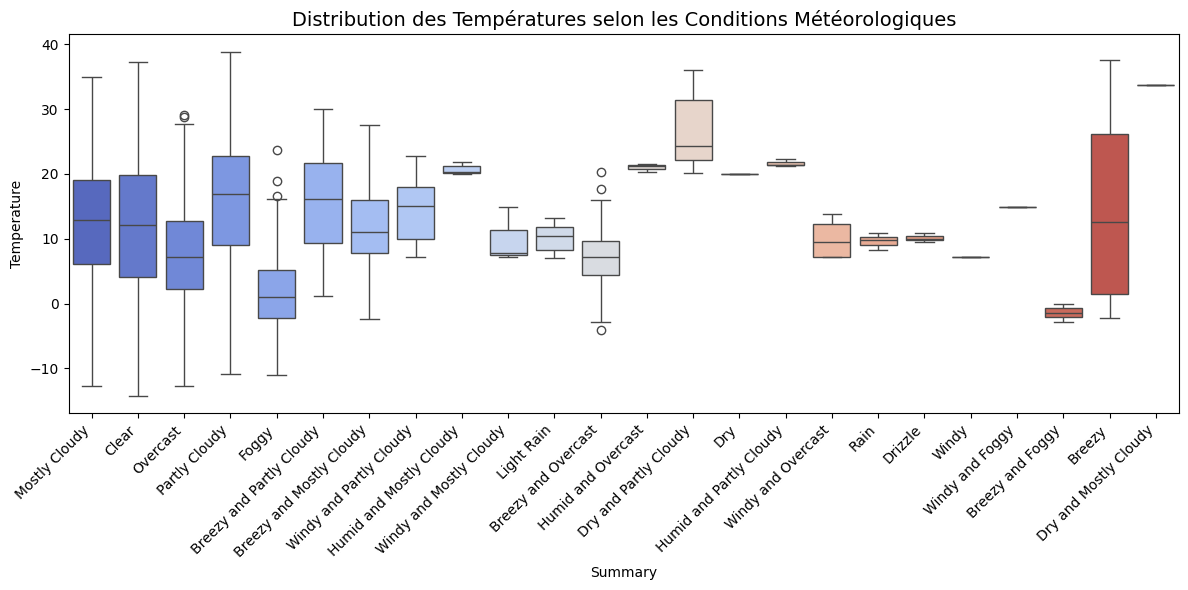

In [ ]:
#Seaborn est parfait pour analyser les distributions statistiques demandées dans la consigne.
#Nous allons créer un graphique (Boxplot) pour voir la répartition des températures selon le type de météo (Summary).
import seaborn as sns
import matplotlib.pyplot as plt

# Conversion des données Spark en Pandas (si pas déjà fait)
# On prend un échantillon si le dataset est trop gros pour la RAM locale
pdf_echantillon = fait_releves.join(dim_condition, "ID_Condition").sample(fraction=0.1).toPandas()

plt.figure(figsize=(12, 6))
# Création d'un Boxplot pour voir la distribution et les valeurs aberrantes
sns.boxplot(x='Summary', y='Temperature', data=pdf_echantillon, palette='coolwarm')
plt.title('Distribution des Températures selon les Conditions Météorologiques', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotation des labels pour la lisibilité
plt.tight_layout()
plt.show()

In [ ]:
#Ici, nous créons un graphique interactif de l'évolution de la température avec un curseur
import plotly.express as px

# Correction : On décommente la conversion de Spark vers Pandas
pdf_tendance = tendance_annuelle.toPandas()

# Création du graphique interactif
fig = px.line(pdf_tendance,
              x='Annee',
              y='Temp_Moyenne_Annuelle',
              title='Évolution Interactive de la Température Moyenne Annuelle (2006-2016)',
              markers=True,
              labels={'Temp_Moyenne_Annuelle': 'Température Moyenne (°C)', 'Annee': 'Année'})

# Ajout d'un slider interactif en bas du graphique
fig.update_xaxes(rangeslider_visible=True)
fig.update_traces(line_color='firebrick', marker=dict(size=10))
fig.update_layout(template='plotly_white')

# Affichage interactif
fig.show()